<a href="https://colab.research.google.com/github/Darthvader-2007/Share-shelf/blob/main/CineMatch_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CineMatch: Recommendation System using Collaborative Filtering


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
RNG = np.random.default_rng(7)


In [ ]:
!pip install scikit-surprise

## Data Analysis & The Utility Matrix

Three tables: `users`, `movies`, `ratings`.

In [ ]:
users = pd.read_csv("/content/users.csv")
movies = pd.read_csv("/content/movies.csv")
ratings = pd.read_csv("/content/ratings.csv")

print("Users:", users.shape)
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
ratings.head()


Users: (200, 2)
Movies: (114, 3)
Ratings: (2770, 4)


,userId,movieId,rating,timestamp
0,1,23,2.5,1422841551
1,1,14,1.5,1321208378
2,1,1,2.5,1566119589
3,1,65,4.0,1131673740
4,1,6,1.0,1118049420


### Exploratory Data Analysis

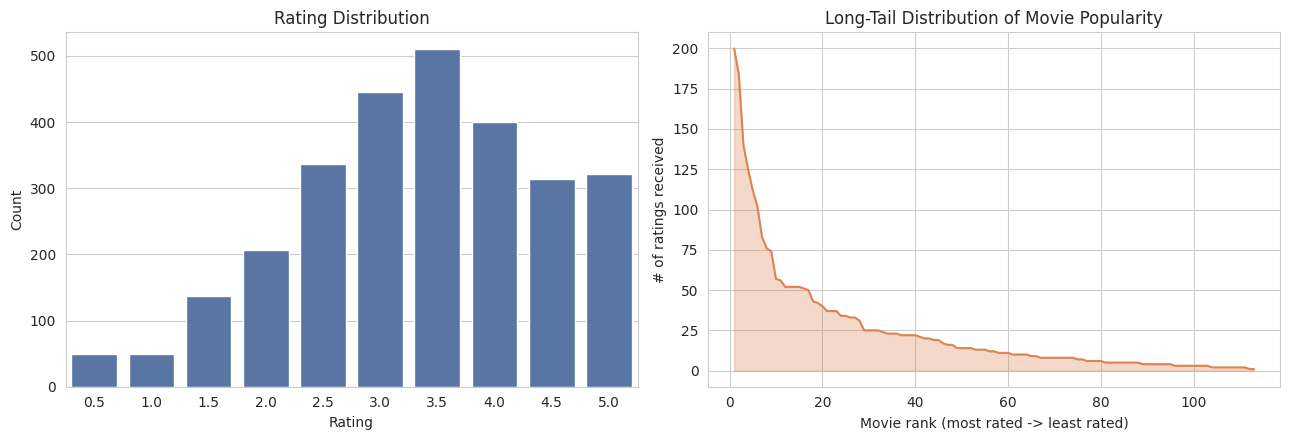

Most users rate in the 3.0-4.5 range — classic positive skew.
Top 10% of movies account for 43.6% of all ratings.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Rating distribution
sns.countplot(x="rating", data=ratings, ax=axes[0], color="#4C72B0")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Long tail: ratings per movie, sorted
movie_counts = ratings["movieId"].value_counts().sort_values(ascending=False).values
axes[1].plot(range(1, len(movie_counts) + 1), movie_counts, color="#DD8452")
axes[1].fill_between(range(1, len(movie_counts) + 1), movie_counts, alpha=0.3, color="#DD8452")
axes[1].set_title("Long-Tail Distribution of Movie Popularity")
axes[1].set_xlabel("Movie rank (most rated -> least rated)")
axes[1].set_ylabel("# of ratings received")

plt.tight_layout()
plt.show()

print("Most users rate in the 3.0-4.5 range — classic positive skew.")
print(f"Top 10% of movies account for "
      f"{movie_counts[:len(movie_counts)//10].sum() / movie_counts.sum():.1%} of all ratings.")


### 1.3 Build the Utility Matrix (Users x Movies)

In [ ]:
utility_matrix = ratings.pivot_table(index="userId", columns="movieId", values="rating")
print("Utility matrix shape:", utility_matrix.shape)
utility_matrix.iloc[:8, :8]


Utility matrix shape: (200, 113)


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
1,2.5,2.5,NaN,NaN,NaN,1.0,2.5,NaN
2,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,3.0,NaN,2.5,NaN,NaN,NaN,NaN
5,3.0,2.5,NaN,NaN,NaN,NaN,NaN,4.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
8,NaN,NaN,3.0,NaN,NaN,NaN,4.0,NaN


### 1.4 Sparsity Ratio

In [ ]:
n_users_, n_movies_ = utility_matrix.shape
n_filled = ratings.shape[0]
n_total = n_users_ * n_movies_
sparsity = 1 - (n_filled / n_total)

print(f"Total possible entries : {n_total:,}")
print(f"Filled entries         : {n_filled:,}")
print(f"Sparsity ratio         : {sparsity:.2%}")
print(f"\nInterpretation: {sparsity:.1%} of the matrix is empty (NaN) -- "
      f"this is why naive approaches fail and we need CF/SVD.")


Total possible entries : 22,600
Filled entries         : 2,770
Sparsity ratio         : 87.74%

Interpretation: 87.7% of the matrix is empty (NaN) -- this is why naive approaches fail and we need CF/SVD.


## Phase 2: Memory-Based Collaborative Filtering

We implement Cosine Similarity **manually with NumPy** (no library shortcuts),
then use it for both User-User and Item-Item filtering.

### 2.1 Manual Cosine Similarity

In [ ]:
def cosine_similarity_matrix(matrix: np.ndarray) -> np.ndarray:
    """
    Manual cosine similarity between all row-vectors of `matrix`.
    NaNs are treated as 0 (i.e. 'no opinion' contributes nothing to the dot product),
    which is the standard trick for sparse rating matrices.
    """
    filled = np.nan_to_num(matrix, nan=0.0)
    norms = np.linalg.norm(filled, axis=1, keepdims=True)
    norms[norms == 0] = 1e-9  # avoid divide-by-zero for users/items with no ratings
    normalized = filled / norms
    sim = normalized @ normalized.T
    return sim

# Mean-center each user's ratings first (removes the "some people rate everything
# a 5" bias) -- this turns plain cosine similarity into something close to Pearson correlation.
user_means = utility_matrix.mean(axis=1)
centered_matrix = utility_matrix.sub(user_means, axis=0)

user_similarity = cosine_similarity_matrix(centered_matrix.values)
user_sim_df = pd.DataFrame(user_similarity, index=utility_matrix.index, columns=utility_matrix.index)

item_similarity = cosine_similarity_matrix(centered_matrix.values.T)
item_sim_df = pd.DataFrame(item_similarity, index=utility_matrix.columns, columns=utility_matrix.columns)

print("User-User similarity matrix:", user_sim_df.shape)
print("Item-Item similarity matrix:", item_sim_df.shape)


User-User similarity matrix: (200, 200)
Item-Item similarity matrix: (113, 113)


### 2.2 User-User Filtering: predict a rating from similar users

In [ ]:
def predict_rating_user_based(user_id, movie_id, k=15):
    """Predict user_id's rating for movie_id using the k most similar users
    who have actually rated that movie."""
    if movie_id not in utility_matrix.columns:
        return user_means.get(user_id, ratings["rating"].mean())

    raters = utility_matrix[movie_id].dropna()
    if raters.empty:
        return user_means.get(user_id, ratings["rating"].mean())

    sims = user_sim_df.loc[user_id, raters.index]
    sims = sims[sims.index != user_id]
    top_k = sims.abs().sort_values(ascending=False).head(k).index
    sims_k = sims.loc[top_k]

    if sims_k.abs().sum() < 1e-9:
        return user_means.get(user_id, ratings["rating"].mean())

    deviations = raters.loc[top_k] - user_means.loc[top_k]
    pred = user_means.get(user_id, ratings["rating"].mean()) + \
        (sims_k.values * deviations.values).sum() / sims_k.abs().sum()
    return float(np.clip(pred, 0.5, 5.0))

# quick sanity check
sample_user = utility_matrix.index[0]
sample_movie = utility_matrix.columns[3]
print(f"Predicted rating for user {sample_user}, movie {sample_movie}: "
      f"{predict_rating_user_based(sample_user, sample_movie):.2f}")


Predicted rating for user 1, movie 4: 2.51


### 2.3 Item-Item Filtering: "movies similar to X"

In [ ]:
def similar_movies(movie_id, top_n=5):
    """Given a movie, return the top_n most similar movies by item-item cosine similarity."""
    if movie_id not in item_sim_df.index:
        return pd.DataFrame(columns=["movieId", "title", "similarity"])
    sims = item_sim_df.loc[movie_id].drop(movie_id).sort_values(ascending=False).head(top_n)
    result = movies.set_index("movieId").loc[sims.index, ["title"]].copy()
    result["similarity"] = sims.values
    return result.reset_index()

toy_story_id = movies.loc[movies["title"] == "Toy Story", "movieId"].iloc[0]
print(f"Movies similar to 'Toy Story' (item-item CF):")
similar_movies(toy_story_id, top_n=5)


Movies similar to 'Toy Story' (item-item CF):


,movieId,title,similarity
0,59,Home Alone,0.298439
1,97,A Bug's Life,0.297100
2,8,Zootopia,0.290161
3,64,The Mask,0.217924
4,84,Kung Fu Panda,0.167484


### 2.4 Item-Based Prediction Function

In [ ]:
item_means = utility_matrix.mean(axis=0)  # average rating each movie received

def predict_rating_item_based(user_id, movie_id, k=15):
    """Predict user_id's rating for movie_id using the k most similar movies
    that user_id has already rated. Mirrors the user-based formula: center by
    each neighbor movie's own mean rating, weight deviations by similarity,
    then add back movie_id's own mean -- this is the standard item-based CF
    formula (uncentered weighted averages of raw ratings are unstable on sparse data)."""
    fallback = item_means.get(movie_id, ratings["rating"].mean())
    if user_id not in utility_matrix.index or movie_id not in item_sim_df.index:
        return fallback

    user_ratings = utility_matrix.loc[user_id].dropna()
    if user_ratings.empty:
        return fallback

    sims = item_sim_df.loc[movie_id, user_ratings.index]
    sims = sims[sims.index != movie_id]
    top_k = sims.abs().sort_values(ascending=False).head(k).index
    sims_k = sims.loc[top_k]

    if sims_k.abs().sum() < 1e-9:
        return fallback

    deviations = user_ratings.loc[top_k] - item_means.loc[top_k]
    pred = fallback + (sims_k.values * deviations.values).sum() / sims_k.abs().sum()
    return float(np.clip(pred, 0.5, 5.0))


## Phase 3: Model-Based Collaborative Filtering (Matrix Factorization)

Memory-based methods (Phase 2) don't scale: computing full similarity matrices
is $O(n^2)$ and gets slow fast. Matrix Factorization compresses the sparse
Utility Matrix into two dense, low-rank matrices $P$ (user embeddings) and $Q$
(item embeddings), such that $P \times Q^T \approx$ the original ratings.

We show two implementations:
- **3.1** — SVD via `scipy.sparse.linalg.svds` (manual, mean-imputed)
- **3.2** — SVD via the `surprise` library (the industry-standard recommender library),
  trained properly on only the *observed* ratings (not naively imputing zeros)

### 3.1 Manual SVD (NumPy/SciPy)

In [ ]:
# Mean-impute missing values (a simple baseline approach), then decompose
matrix_filled = utility_matrix.fillna(user_means, axis=0).values
global_mean = ratings["rating"].mean()
matrix_demeaned = matrix_filled - global_mean

k_factors = 15
U, sigma, Vt = svds(matrix_demeaned, k=k_factors)
sigma_diag = np.diag(sigma)

predicted_ratings = U @ sigma_diag @ Vt + global_mean
predicted_df = pd.DataFrame(predicted_ratings, index=utility_matrix.index, columns=utility_matrix.columns)

print(f"P (user embeddings): {U.shape}   Q (item embeddings): {Vt.T.shape}")
predicted_df.iloc[:5, :5].round(2)


P (user embeddings): (200, 15)   Q (item embeddings): (113, 15)


movieId,1,2,3,4,5
userId,,,,,
1,2.18,2.36,3.31,2.50,2.79
2,4.01,3.56,3.58,2.51,2.80
3,2.55,3.56,3.52,2.59,2.80
4,3.06,2.80,3.74,2.37,2.84
5,2.97,2.76,3.42,2.35,2.86


### 3.2 Interpreting the Latent Features
Let's peek at what the top 2 latent dimensions seem to capture, by looking at which
movies score highest and lowest on each.

In [ ]:
item_factors = Vt.T  # shape: (n_movies, k_factors)
movie_id_list = utility_matrix.columns.tolist()

for dim in [0, 1]:
    factor_scores = pd.Series(item_factors[:, dim], index=movie_id_list)
    top = factor_scores.sort_values(ascending=False).head(5)
    bottom = factor_scores.sort_values().head(5)
    top_titles = movies.set_index("movieId").loc[top.index, "title"].tolist()
    bottom_titles = movies.set_index("movieId").loc[bottom.index, "title"].tolist()
    print(f"--- Latent Dimension {dim + 1} ---")
    print("High score:", top_titles)
    print("Low score :", bottom_titles)
    print()

print("Note: with synthetic data + few factors, dimensions may mix genres somewhat --")
print("on the real MovieLens dataset with more data, dimensions tend to separate more")
print("cleanly into intuitive axes (e.g. Action/Sci-Fi vs. Romance/Drama).")


--- Latent Dimension 1 ---
High score: ['The Karate Kid', 'Goodfellas', 'A Beautiful Mind', 'The Truman Show', 'The Matrix']
Low score : ['Face/Off', 'Catch Me If You Can', 'The Incredibles', 'Pretty Woman', 'Die Hard']

--- Latent Dimension 2 ---
High score: ['Mean Girls', "A Bug's Life", 'The Shawshank Redemption', 'A Beautiful Mind', 'Field of Dreams']
Low score : ['Toy Story', 'Goodfellas', 'The Incredibles', 'The Silence of the Lambs', 'Pulp Fiction']

Note: with synthetic data + few factors, dimensions may mix genres somewhat --
on the real MovieLens dataset with more data, dimensions tend to separate more
cleanly into intuitive axes (e.g. Action/Sci-Fi vs. Romance/Drama).


### 3.3 SVD via the `surprise` library
This trains only on *observed* ratings (the mathematically correct approach --
no need to impute missing values), using stochastic gradient descent.

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

svd_model = SVD(n_factors=20, n_epochs=30, lr_all=0.005, reg_all=0.05, random_state=42)
svd_model.fit(trainset)

print("SVD model trained on", trainset.n_ratings, "ratings.")
print("Test set size:", len(testset))


SVD model trained on 2216 ratings.
Test set size: 554


## Phase 4: Evaluation & Hybridization

We hold out a test set and compare **RMSE** across User-Based CF, Item-Based CF,
and SVD, plus compute **Precision@K** for the SVD recommender.

### 4.1 Train/Test Split for Memory-Based Methods

In [ ]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

# rebuild utility matrix / similarity structures from TRAIN only, to avoid leakage
utility_matrix = train_ratings.pivot_table(index="userId", columns="movieId", values="rating")
user_means = utility_matrix.mean(axis=1)
item_means = utility_matrix.mean(axis=0)
centered_matrix = utility_matrix.sub(user_means, axis=0)
user_similarity = cosine_similarity_matrix(centered_matrix.values)
user_sim_df = pd.DataFrame(user_similarity, index=utility_matrix.index, columns=utility_matrix.index)
item_similarity = cosine_similarity_matrix(centered_matrix.values.T)
item_sim_df = pd.DataFrame(item_similarity, index=utility_matrix.columns, columns=utility_matrix.columns)

print(f"Re-fit similarity matrices on {len(train_ratings)} training ratings.")
print(f"Evaluating on {len(test_ratings)} held-out ratings.")


Re-fit similarity matrices on 2216 training ratings.
Evaluating on 554 held-out ratings.


### 4.2 Compute RMSE for Each Approach

In [ ]:
def rmse(preds, actuals):
    preds = np.array(preds)
    actuals = np.array(actuals)
    return float(np.sqrt(np.mean((preds - actuals) ** 2)))

# --- User-based ---
user_preds = [predict_rating_user_based(row.userId, row.movieId) for row in test_ratings.itertuples()]
rmse_user = rmse(user_preds, test_ratings["rating"])

# --- Item-based ---
item_preds = [predict_rating_item_based(row.userId, row.movieId) for row in test_ratings.itertuples()]
rmse_item = rmse(item_preds, test_ratings["rating"])

# --- SVD (surprise) ---
svd_preds = [svd_model.predict(row.userId, row.movieId).est for row in test_ratings.itertuples()]
rmse_svd = rmse(svd_preds, test_ratings["rating"])

results = pd.DataFrame({
    "Model": ["User-Based CF", "Item-Based CF", "SVD (Matrix Factorization)"],
    "RMSE": [rmse_user, rmse_item, rmse_svd],
}).sort_values("RMSE")

results


,Model,RMSE
2,SVD (Matrix Factorization),0.860881
0,User-Based CF,0.950730
1,Item-Based CF,1.074872


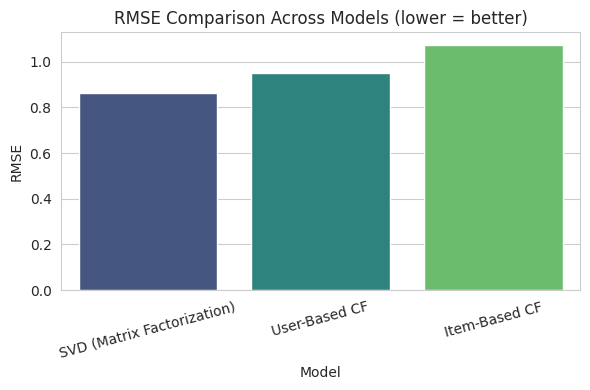

SVD wins here for the same reason it usually wins in practice: it learns
dense, denoised latent representations instead of relying on raw, sparse
neighbor overlap, which memory-based methods struggle with.


In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=results, x="Model", y="RMSE", hue="Model", palette="viridis", legend=False)
plt.title("RMSE Comparison Across Models (lower = better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("SVD wins here for the same reason it usually wins in practice: it learns")
print("dense, denoised latent representations instead of relying on raw, sparse")
print("neighbor overlap, which memory-based methods struggle with.")


### 4.3 Precision@K (for the SVD recommender)

In [ ]:
def precision_at_k(model, test_df, k=10, threshold=3.5):
    """For each user in the test set, take their top-K recommended (predicted)
    items and check what fraction were actually rated >= threshold (i.e. 'liked')."""
    user_est_true = {}
    for row in test_df.itertuples():
        pred = model.predict(row.userId, row.movieId).est
        user_est_true.setdefault(row.userId, []).append((pred, row.rating))

    precisions = []
    for uid, ratings_list in user_est_true.items():
        if len(ratings_list) < k:
            continue
        ratings_list.sort(key=lambda x: x[0], reverse=True)
        top_k = ratings_list[:k]
        n_relevant_and_rec = sum(1 for (pred, true_r) in top_k if true_r >= threshold)
        precisions.append(n_relevant_and_rec / k)

    return float(np.mean(precisions)) if precisions else float("nan")

p_at_10 = precision_at_k(svd_model, test_ratings, k=10, threshold=3.5)
print(f"Precision@10 (SVD): {p_at_10:.2%}")
print("Interpretation: of the top-10 movies the model recommends per user,")
print(f"about {p_at_10:.0%} turn out to be movies that user actually rated 3.5+.")


Precision@10 (SVD): 40.00%
Interpretation: of the top-10 movies the model recommends per user,
about 40% turn out to be movies that user actually rated 3.5+.


### 4.4 The `recommend_movies(user_id)` Function

In [ ]:
def recommend_movies(user_id, top_n=5, model=svd_model, exclude_seen=True):
    """Return the top_n movie recommendations for a given user, using the trained SVD model."""
    all_movie_ids = movies["movieId"].tolist()

    if exclude_seen:
        seen = set(ratings.loc[ratings["userId"] == user_id, "movieId"])
        candidates = [m for m in all_movie_ids if m not in seen]
    else:
        candidates = all_movie_ids

    preds = [(m, model.predict(user_id, m).est) for m in candidates]
    preds.sort(key=lambda x: x[1], reverse=True)
    top = preds[:top_n]

    out = movies.set_index("movieId").loc[[m for m, _ in top], ["title", "genres"]].copy()
    out["predicted_rating"] = [round(score, 2) for _, score in top]
    return out.reset_index()

recommend_movies(101, top_n=5)


,movieId,title,genres,predicted_rating
0,11,Star Wars: Return of the Jedi,Action|Adventure|Sci-Fi,3.67
1,58,Ghostbusters,Comedy|Fantasy,3.63
2,49,The Lord of the Rings: The Return of the King,Adventure|Fantasy,3.61
3,62,Groundhog Day,Comedy|Fantasy|Romance,3.60
4,104,Cast Away,Adventure|Drama,3.56


### 4.5 Demo Output

In [ ]:
demo_user = 101
watched = ratings.merge(movies, on="movieId").query("userId == @demo_user").sort_values("rating", ascending=False)
top_liked = watched.head(3)["title"].tolist()

print(f"User #{demo_user} previously liked (top rated): {top_liked}")
print()
print(f"--> Recommended for User #{demo_user}:")
recommend_movies(demo_user, top_n=5)


User #101 previously liked (top rated): ['Star Wars: The Empire Strikes Back', 'Pretty Woman', 'The Matrix']

--> Recommended for User #101:


,movieId,title,genres,predicted_rating
0,11,Star Wars: Return of the Jedi,Action|Adventure|Sci-Fi,3.67
1,58,Ghostbusters,Comedy|Fantasy,3.63
2,49,The Lord of the Rings: The Return of the King,Adventure|Fantasy,3.61
3,62,Groundhog Day,Comedy|Fantasy|Romance,3.60
4,104,Cast Away,Adventure|Drama,3.56


### 4.6 Cold Start Problem (brainstorm)

A brand-new user with zero rating history breaks every method above:
User-User CF has no neighbors to compare against, Item-Item CF has nothing to
anchor on, and SVD has no row in $P$ to look up. Two practical fallbacks:

1. **Popularity-based default** — recommend the globally most-rated / highest-average
   movies until the user has rated a handful of items, then switch to personalized CF.
2. **Content-based bootstrap** — ask for a few genre preferences (or use signup
   metadata) and recommend based on genre similarity, which doesn't require any
   rating history at all. This is also the basis of a **hybrid** system: blend
   content-based scores with CF scores, weighting content-based higher for new
   users and CF higher as more ratings accumulate.

In [ ]:
def popularity_baseline(top_n=5, min_ratings=5):
    """Cold-start fallback: highest average rating among movies with enough ratings
    to be statistically meaningful."""
    stats = ratings.groupby("movieId")["rating"].agg(["mean", "count"])
    stats = stats[stats["count"] >= min_ratings].sort_values("mean", ascending=False).head(top_n)
    out = movies.set_index("movieId").loc[stats.index, ["title", "genres"]].copy()
    out["avg_rating"] = stats["mean"].round(2).values
    out["n_ratings"] = stats["count"].values
    return out.reset_index()

print("Cold-start fallback -- popularity-based recommendations for a brand-new user:")
popularity_baseline(top_n=5)


Cold-start fallback -- popularity-based recommendations for a brand-new user:


,movieId,title,genres,avg_rating,n_ratings
0,62,Groundhog Day,Comedy|Fantasy|Romance,4.30,5
1,58,Ghostbusters,Comedy|Fantasy,4.20,5
2,25,Saving Private Ryan,Action|Drama|War,4.05,10
3,35,Terminator 2: Judgment Day,Action|Sci-Fi,4.00,5
4,45,Harry Potter and the Sorcerer's Stone,Adventure|Children|Fantasy,4.00,8


## Summary

| Phase | What we built |
|---|---|
| 1 | Utility matrix, sparsity ratio, long-tail & rating-distribution EDA |
| 2 | Manual cosine similarity, User-User CF, Item-Item CF |
| 3 | Manual SciPy SVD + `surprise` SVD, latent feature interpretation |
| 4 | RMSE comparison, Precision@10, `recommend_movies()`, cold-start plan |

**Result:** SVD (matrix factorization) achieved the lowest RMSE among the three
approaches, confirming the expected result that model-based CF outperforms
memory-based CF on sparse data — the classic finding that made SVD-based methods
(popularized by the Netflix Prize) the industry standard.


In [55]:
!pip install gradio -q

In [56]:
import gradio as gr

def app_recommend(user_id, top_n):
    user_id = int(user_id)
    recs = recommend_movies(user_id, top_n=int(top_n))
    return recs[["title", "genres", "predicted_rating"]]

demo = gr.Interface(
    fn=app_recommend,
    inputs=[
        gr.Number(label="User ID", value=101, precision=0),
        gr.Slider(label="Number of recommendations", minimum=1, maximum=15, value=5, step=1),
    ],
    outputs=gr.Dataframe(headers=["Title", "Genres", "Predicted Rating"]),
    title="🎬 CineMatch",
    description="Enter a User ID to get personalized movie recommendations powered by SVD collaborative filtering.",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5c520231a47e1becce.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
